<a href="https://colab.research.google.com/github/Jigyasa-sharma7/Pollution-Level-Forecasting/blob/main/notebooks/02_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
df = pd.read_csv("/content/pollution_model_data.csv")

In [20]:
df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,datetime
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin,2013-03-01 00:00:00
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin,2013-03-01 01:00:00
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin,2013-03-01 02:00:00
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin,2013-03-01 03:00:00
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin,2013-03-01 04:00:00


In [21]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Shape: (412028, 19)

Columns:
['No', 'year', 'month', 'day', 'hour', 'PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'wd', 'WSPM', 'station', 'datetime']


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 412028 entries, 0 to 412027
Data columns (total 19 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   No        412028 non-null  int64  
 1   year      412028 non-null  int64  
 2   month     412028 non-null  int64  
 3   day       412028 non-null  int64  
 4   hour      412028 non-null  int64  
 5   PM2.5     412028 non-null  float64
 6   PM10      412028 non-null  float64
 7   SO2       412028 non-null  float64
 8   NO2       412028 non-null  float64
 9   CO        412028 non-null  float64
 10  O3        412028 non-null  float64
 11  TEMP      412028 non-null  float64
 12  PRES      412028 non-null  float64
 13  DEWP      412028 non-null  float64
 14  RAIN      412028 non-null  float64
 15  wd        412028 non-null  object 
 16  WSPM      412028 non-null  float64
 17  station   412028 non-null  object 
 18  datetime  412028 non-null  object 
dtypes: float64(11), int64(5), object(3)
memory u

One thing we'll need to remember: when loading from CSV, datetime will initially become an object/string again.

So we'll convert it back:

In [25]:
df["datetime"] = pd.to_datetime(df["datetime"])

In [26]:
print(df["datetime"].dtype)

datetime64[ns]


First EDA step: Basic statistics

In [27]:
df.describe()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM,datetime
count,412028.000000,412028.000000,412028.000000,412028.000000,412028.000000,412028.000000,412028.000000,412028.000000,412028.000000,412028.000000,412028.000000,412028.000000,412028.000000,412028.000000,412028.000000,412028.000000,412028
mean,17519.734215,2014.661557,6.517402,15.731640,11.489348,79.791197,104.807664,15.865820,50.669985,1235.163133,56.921073,13.485027,1010.784419,2.452197,0.063957,1.727103,2015-02-28 22:44:03.172793856
min,1.000000,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,0.285600,1.026500,100.000000,0.214200,-19.900000,982.400000,-43.400000,0.000000,0.000000,2013-03-01 00:00:00
25%,8730.000000,2014.000000,4.000000,8.000000,5.000000,20.000000,36.000000,3.000000,23.000000,500.000000,10.000000,3.100000,1002.300000,-9.000000,0.000000,0.900000,2014-02-27 17:00:00
50%,17523.000000,2015.000000,7.000000,16.000000,11.000000,55.000000,82.000000,7.000000,43.000000,900.000000,44.000000,14.400000,1010.400000,3.000000,0.000000,1.400000,2015-03-01 02:00:00
75%,26283.000000,2016.000000,10.000000,23.000000,18.000000,111.000000,145.000000,20.000000,71.000000,1500.000000,81.000000,23.200000,1019.000000,15.100000,0.000000,2.200000,2016-02-29 02:00:00
max,35064.000000,2017.000000,12.000000,31.000000,23.000000,957.000000,995.000000,500.000000,290.000000,10000.000000,1071.000000,41.600000,1042.800000,29.100000,72.500000,13.200000,2017-02-28 23:00:00
std,10132.929132,1.178980,3.452462,8.796408,6.933320,80.809802,92.228296,21.813108,35.184018,1161.304176,56.975770,11.437085,10.468293,13.806305,0.817761,1.245397,NaN


In [28]:
df["PM2.5"].describe()

,PM2.5
count,412028.000000
mean,79.791197
std,80.809802
min,2.000000
25%,20.000000
50%,55.000000
75%,111.000000
max,957.000000


## 1. PM2.5 Distribution

We first examine the distribution of PM2.5 concentrations to understand the typical pollution levels, variability, skewness, and presence of extreme values.

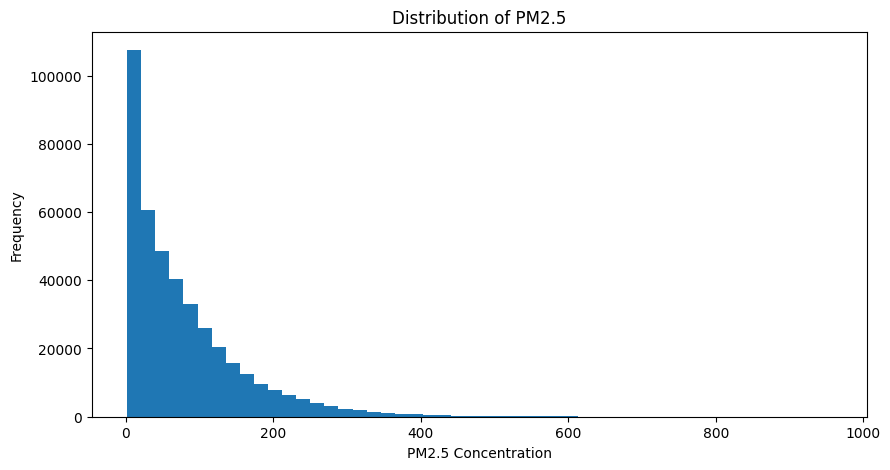

In [29]:
plt.figure(figsize=(10, 5))

plt.hist(df["PM2.5"], bins=50)

plt.xlabel("PM2.5 Concentration")
plt.ylabel("Frequency")
plt.title("Distribution of PM2.5")

plt.show()

### Observation

The PM2.5 distribution is strongly right-skewed (positively skewed). Most observations have relatively low to moderate PM2.5 concentrations, while a smaller number of observations have very high concentrations. The long right tail indicates the presence of extreme pollution episodes.

The mean PM2.5 concentration (79.79) is higher than the median (55), which further supports the positive skewness of the distribution.

The maximum PM2.5 value is 957, indicating substantial variation in pollution levels across time and monitoring stations.

## 2. PM2.5 Boxplot

A boxplot is used to examine the spread of PM2.5 values and identify potential outliers.

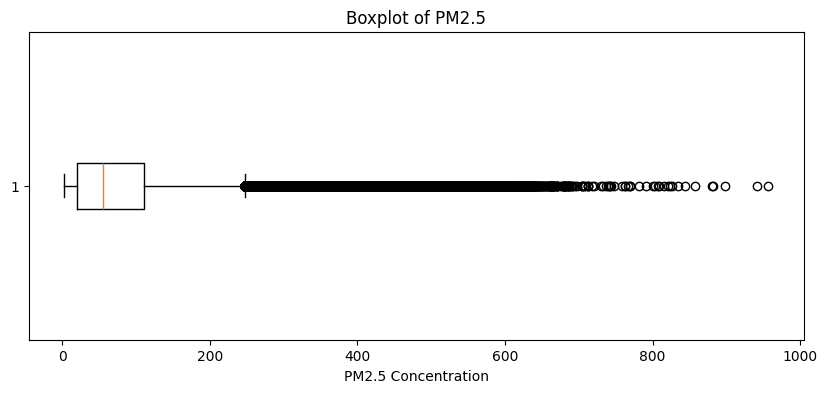

In [30]:
plt.figure(figsize=(10, 4))

plt.boxplot(df["PM2.5"], vert=False)

plt.xlabel("PM2.5 Concentration")
plt.title("Boxplot of PM2.5")

plt.show()

### Observation

The boxplot shows that PM2.5 has a strong right-skewed distribution with a large number of observations beyond the upper whisker. These observations represent unusually high PM2.5 concentrations.

The median PM2.5 concentration is approximately 55, while the middle 50% of observations lie roughly between 20 and 111. The presence of many high-value observations is consistent with the right-skewed distribution observed in the histogram.

These extreme values are not removed because they may represent genuine high-pollution episodes rather than data errors. Therefore, they are retained for further analysis and modeling.

## 3. PM2.5 Levels by Monitoring Station

The dataset contains observations from 12 monitoring stations. We compare the average PM2.5 concentration across stations to identify differences in pollution levels between locations.

In [31]:
station_pm25 = (
    df.groupby("station")["PM2.5"]
      .mean()
      .sort_values(ascending=False)
)

print(station_pm25)

station
Dongsi           86.194297
Wanshouxigong    84.997541
Nongzhanguan     84.838483
Gucheng          83.852089
Wanliu           83.374716
Guanyuan         82.933372
Aotizhongxin     82.773611
Tiantan          82.164911
Shunyi           79.491602
Changping        71.099743
Huairou          69.626367
Dingling         65.989497
Name: PM2.5, dtype: float64


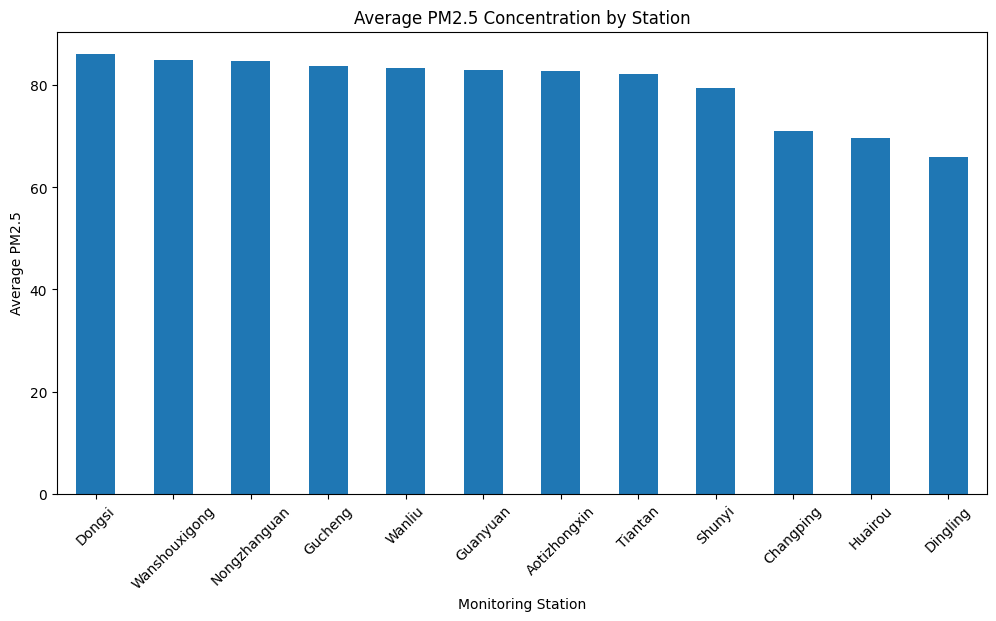

In [32]:
plt.figure(figsize=(12, 6))

station_pm25.plot(kind="bar")

plt.xlabel("Monitoring Station")
plt.ylabel("Average PM2.5")
plt.title("Average PM2.5 Concentration by Station")
plt.xticks(rotation=45)

plt.show()

### Observation

The average PM2.5 concentration varies across the 12 monitoring stations.

Dongsi has the highest average PM2.5 concentration, while Dingling has the lowest. Several stations such as Wanshouxigong and Nongzhanguan also show relatively high average PM2.5 levels.

This variation indicates that pollution levels differ by location. Therefore, the monitoring station is an important feature and will be retained for the machine learning model.

## 4. PM2.5 Variation by Hour

Air pollution can vary throughout the day because of changes in traffic, atmospheric conditions, human activity, and pollutant dispersion.

We examine the average PM2.5 concentration for each hour of the day.

In [33]:
hourly_pm25 = (
    df.groupby("hour")["PM2.5"]
      .mean()
)

print(hourly_pm25)

hour
0     87.588425
1     86.559755
2     84.463228
3     82.014665
4     79.299768
5     76.395365
6     74.240960
7     73.272242
8     74.533339
9     76.059757
10    77.122795
11    77.351682
12    76.858321
13    76.220075
14    75.326829
15    74.523816
16    74.099249
17    75.367208
18    78.022090
19    82.497017
20    86.555549
21    88.780560
22    88.887939
23    88.606751
Name: PM2.5, dtype: float64


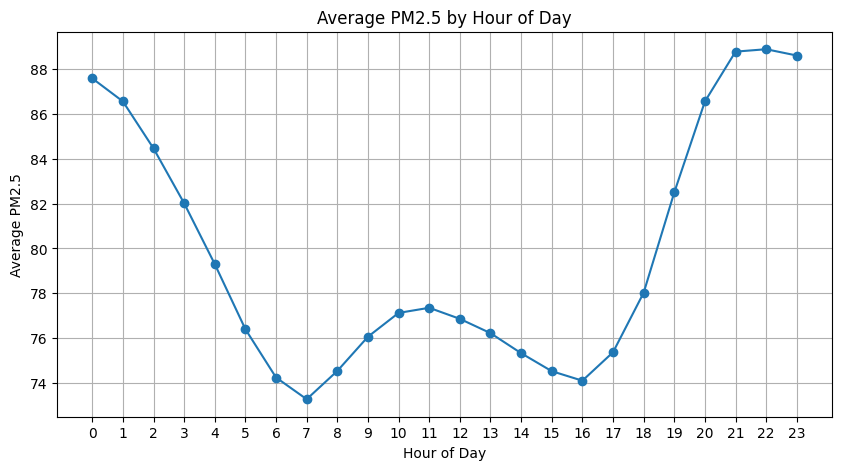

In [34]:
plt.figure(figsize=(10, 5))

plt.plot(hourly_pm25.index, hourly_pm25.values, marker="o")

plt.xlabel("Hour of Day")
plt.ylabel("Average PM2.5")
plt.title("Average PM2.5 by Hour of Day")
plt.xticks(range(24))

plt.grid(True)
plt.show()

### Observation

The average PM2.5 concentration varies considerably throughout the day.

PM2.5 levels are relatively high during the late evening and nighttime, reaching the highest average value of approximately 88.89 at 22:00. The lowest average value is approximately 73.27 at 07:00.

The variation in PM2.5 concentration across different hours suggests that time of day may be an important factor in predicting pollution levels.

However, the hourly pattern may also be influenced by other factors such as weather conditions, wind speed, temperature, and atmospheric pressure, which will be examined in later stages of the EDA.

How does PM2.5 change over the years/months?

In [35]:
monthly_pm25 = (
    df.groupby(["year", "month"])["PM2.5"]
      .mean()
      .reset_index()
)

print(monthly_pm25.head(12))

    year  month       PM2.5
0   2013      3  104.888301
1   2013      4   62.139109
2   2013      5   81.846225
3   2013      6  102.444121
4   2013      7   67.909378
5   2013      8   60.628056
6   2013      9   76.123027
7   2013     10   91.990167
8   2013     11   73.890435
9   2013     12   78.452888
10  2014      1   98.017032
11  2014      2  148.322973


In [36]:
monthly_pm25["date"] = pd.to_datetime(
    monthly_pm25[["year", "month"]].assign(day=1)
)

monthly_pm25.head()

,year,month,PM2.5,date
0,2013,3,104.888301,2013-03-01
1,2013,4,62.139109,2013-04-01
2,2013,5,81.846225,2013-05-01
3,2013,6,102.444121,2013-06-01
4,2013,7,67.909378,2013-07-01


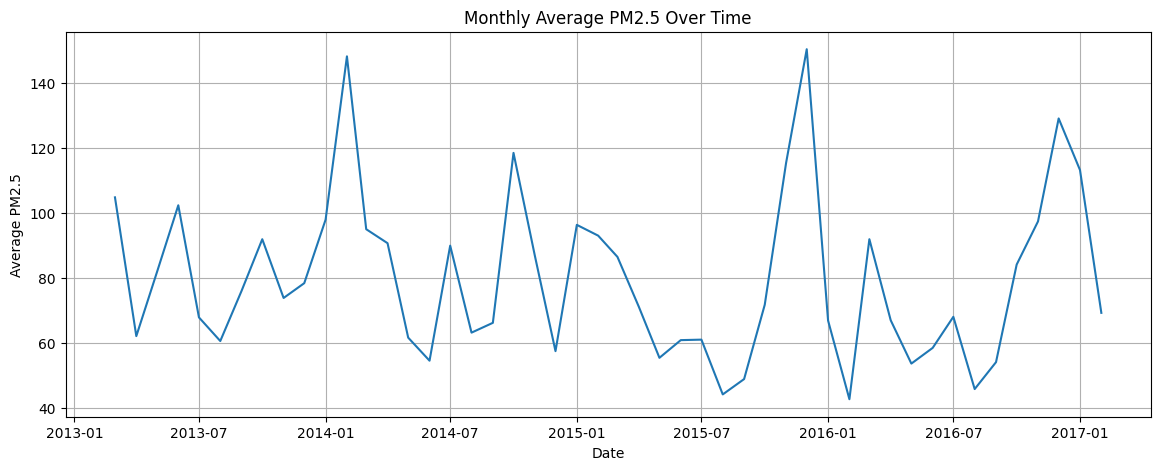

In [37]:
plt.figure(figsize=(14, 5))

plt.plot(
    monthly_pm25["date"],
    monthly_pm25["PM2.5"]
)

plt.xlabel("Date")
plt.ylabel("Average PM2.5")
plt.title("Monthly Average PM2.5 Over Time")

plt.grid(True)
plt.show()

### Observation

The monthly average PM2.5 concentration shows noticeable fluctuations over the study period from March 2013 to February 2017.

The pollution level does not remain constant over time. Periods of relatively moderate PM2.5 are followed by periods of higher concentrations, producing a repeated up-and-down pattern.

The higher PM2.5 levels appear to occur during certain periods of the year, suggesting that there may be a seasonal component to air pollution. This will be investigated further by comparing PM2.5 concentrations across different months and seasons.

Instead of guessing from the graph, let's prove whether there is seasonality.
We'll calculate the average PM2.5 for each month across all years.

In [38]:
monthly_seasonality = (
    df.groupby("month")["PM2.5"]
      .mean()
)

print(monthly_seasonality)

month
1      93.667037
2      87.543623
3      94.660678
4      72.734890
5      63.105338
6      69.091971
7      71.744853
8      53.473014
9      61.478105
10     91.726800
11     93.331519
12    104.581244
Name: PM2.5, dtype: float64


### Observation

The monthly average PM2.5 concentration shows a clear seasonal pattern.

PM2.5 concentrations are generally higher from October to March and lower from April to September. December has the highest average PM2.5 concentration at approximately 104.58, while August has the lowest at approximately 53.47.

This indicates that the month of the year is an important factor associated with PM2.5 concentration. Seasonal changes in weather conditions and atmospheric dispersion may contribute to these variations.

Therefore, month and other time-related features should be retained for the forecasting model.

##PM2.5 vs Temperature

In [39]:
temp_corr = df["PM2.5"].corr(df["TEMP"])

print("Correlation between PM2.5 and Temperature:", temp_corr)

Correlation between PM2.5 and Temperature: -0.1307517216228212


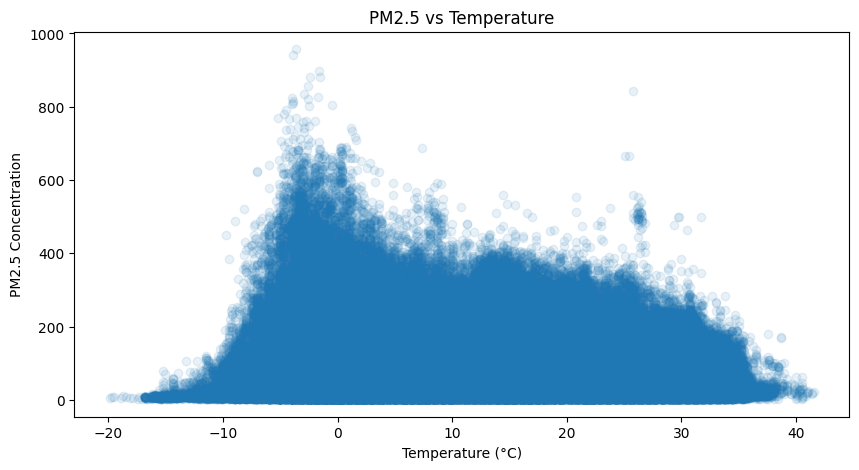

In [40]:
plt.figure(figsize=(10, 5))

plt.scatter(
    df["TEMP"],
    df["PM2.5"],
    alpha=0.1
)

plt.xlabel("Temperature (°C)")
plt.ylabel("PM2.5 Concentration")
plt.title("PM2.5 vs Temperature")

plt.show()

### Observation

The correlation between PM2.5 and temperature is approximately -0.131, indicating a weak negative linear relationship.

This suggests that higher temperatures are generally associated with slightly lower PM2.5 concentrations in the dataset. However, the weak correlation indicates that temperature alone does not have a strong linear relationship with PM2.5.

Correlation does not imply causation, and other factors such as wind speed, atmospheric pressure, rainfall, and other pollutants may also influence PM2.5 levels.

##PM2.5 vs Wind Speed

In [42]:
wind_corr = df["PM2.5"].corr(df["WSPM"])

print("Correlation between PM2.5 and Wind Speed:", wind_corr)

Correlation between PM2.5 and Wind Speed: -0.27217940121125994


### Observation

The correlation between PM2.5 and wind speed (WSPM) is approximately -0.272.

This indicates a weak-to-moderate negative linear relationship. Higher wind speeds tend to be associated with lower PM2.5 concentrations.

Wind can influence the dispersion of pollutants in the atmosphere, which may contribute to lower PM2.5 concentrations. However, correlation does not establish causation, and other environmental factors may also influence PM2.5 levels.

Compared with temperature (-0.131), wind speed (-0.272) has a stronger negative correlation with PM2.5 in this dataset.

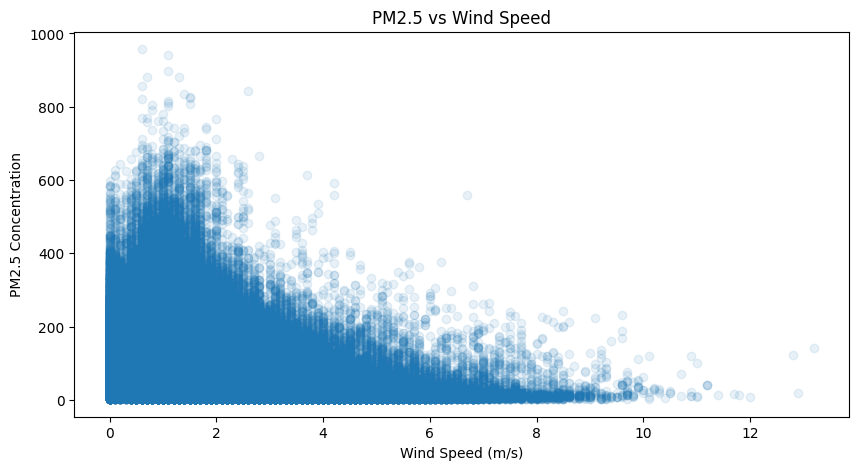

In [43]:
plt.figure(figsize=(10, 5))

plt.scatter(
    df["WSPM"],
    df["PM2.5"],
    alpha=0.1
)

plt.xlabel("Wind Speed (m/s)")
plt.ylabel("PM2.5 Concentration")
plt.title("PM2.5 vs Wind Speed")

plt.show()

##PM2.5 vs Rain

In [44]:
rain_corr = df["PM2.5"].corr(df["RAIN"])

print("Correlation between PM2.5 and Rainfall:", rain_corr)

Correlation between PM2.5 and Rainfall: -0.014356034696813725


### Observation

The correlation between PM2.5 and rainfall is approximately -0.014, which is very close to zero.

This indicates that there is almost no linear relationship between rainfall and PM2.5 in the dataset based on Pearson correlation.

However, this does not mean that rainfall has no influence on air pollution. Rainfall is highly unevenly distributed in the dataset, with most hourly observations having zero rainfall. Therefore, a simple correlation may not capture all possible effects of rainfall on PM2.5.

##PM2.5 vs Atmospheric Pressure

In [45]:
pres_corr = df["PM2.5"].corr(df["PRES"])

print("Correlation between PM2.5 and Atmospheric Pressure:", pres_corr)

Correlation between PM2.5 and Atmospheric Pressure: 0.018281865553080513


### Observation

The correlation between PM2.5 and atmospheric pressure is approximately 0.018, which is very close to zero.

This indicates that atmospheric pressure has almost no linear correlation with PM2.5 in this dataset.

Among the weather variables examined so far, wind speed shows the strongest linear relationship with PM2.5, while rainfall and atmospheric pressure show very weak linear relationships.

However, low correlation does not necessarily mean that a feature is useless for machine learning, because the model may identify non-linear relationships or interactions between multiple features.

##PM2.5 vs DEWP — Dew Point Temperature

In [46]:
dewp_corr = df["PM2.5"].corr(df["DEWP"])

print("Correlation between PM2.5 and Dew Point Temperature:", dewp_corr)

Correlation between PM2.5 and Dew Point Temperature: 0.11504531709087505


### Observation

The correlation between PM2.5 and dew point temperature (DEWP) is approximately 0.115.

This indicates a weak positive linear relationship, meaning that higher dew point temperatures tend to be associated with slightly higher PM2.5 concentrations.

However, the correlation is weak, so dew point temperature alone does not have a strong linear relationship with PM2.5.

Among the weather variables examined, wind speed has the strongest linear relationship with PM2.5, while rainfall and atmospheric pressure have correlations very close to zero.

##Correlation Between PM2.5 and Other Pollutants

In [47]:
pollutants = ["PM10", "SO2", "NO2", "CO", "O3"]

pollutant_corr = df[pollutants + ["PM2.5"]].corr()["PM2.5"].drop("PM2.5")

print(pollutant_corr.sort_values(ascending=False))

PM10    0.881555
CO      0.782140
NO2     0.665227
SO2     0.478119
O3     -0.150698
Name: PM2.5, dtype: float64


## 6. Correlation Between PM2.5 and Other Pollutants

We examined the Pearson correlation between PM2.5 and the other major pollutant variables: PM10, CO, NO2, SO2, and O3.

### Observation

PM10 has the strongest positive correlation with PM2.5 (0.882), indicating that the two particulate pollutants tend to increase together.

CO also shows a strong positive correlation with PM2.5 (0.782), followed by NO2 (0.665) and SO2 (0.478).

O3 has a weak negative correlation with PM2.5 (-0.151), indicating that their linear relationship is relatively weak and tends in the opposite direction.

These correlations suggest that pollutant concentrations contain useful information for predicting PM2.5. However, correlation does not imply causation.

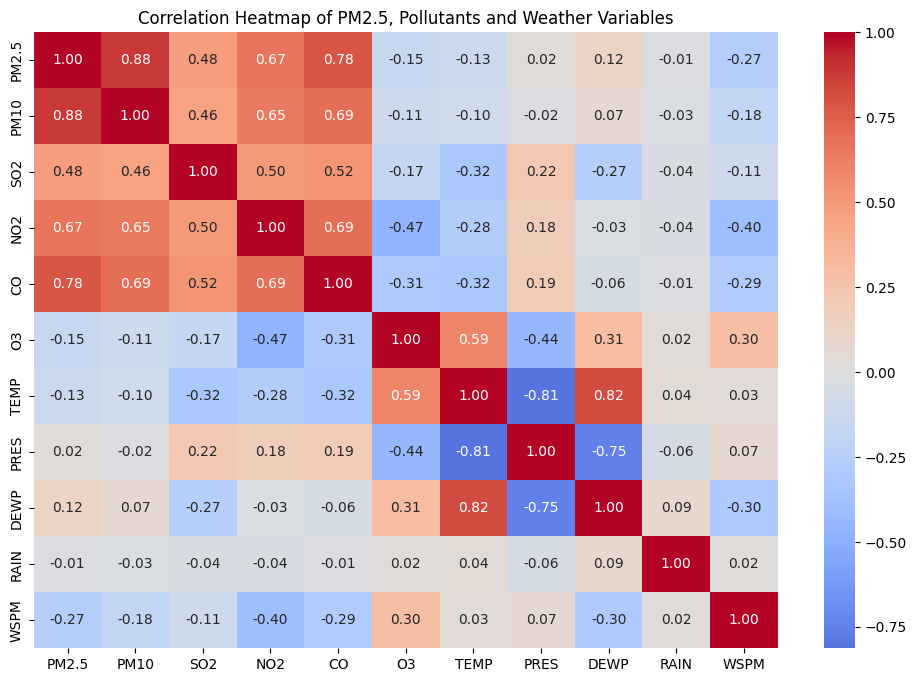

In [50]:
plt.figure(figsize=(12, 8))

corr_matrix = df[
    ["PM2.5", "PM10", "SO2", "NO2", "CO", "O3",
     "TEMP", "PRES", "DEWP", "RAIN", "WSPM"]
].corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of PM2.5, Pollutants and Weather Variables")
plt.show()